
Nothing done.


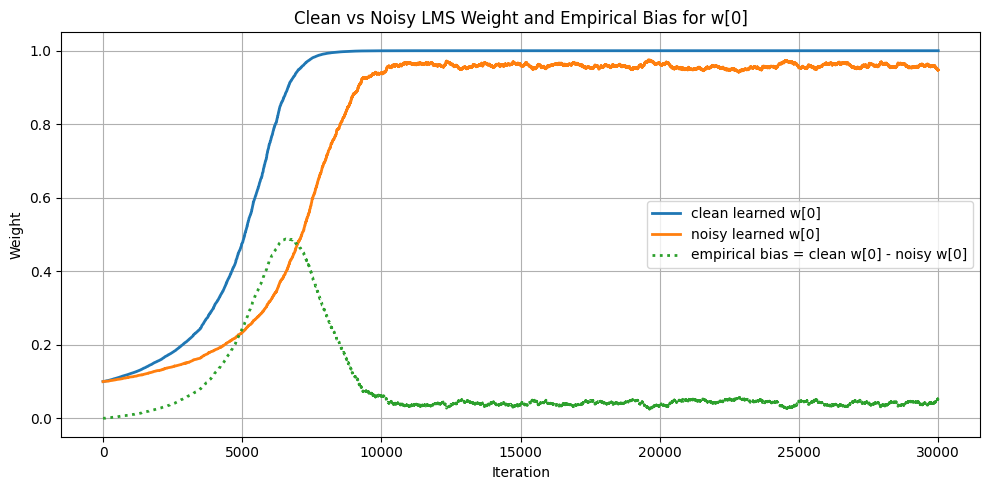

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# Helper functions
# -------------------------------------------------

def past_vector(signal, n, L):
    """
    Returns [signal[n], signal[n-1], ..., signal[n-L+1]]
    with zero-padding for negative indices.
    """
    vec = np.zeros(L)
    for k in range(L):
        if n - k >= 0:
            vec[k] = signal[n - k]

    return vec


def moving_average(x, window):
    """
    Simple moving average for smoother plots.
    """
    window = min(window, len(x))
    kernel = np.ones(window) / window
    return np.convolve(x, kernel, mode="same")


def run_noisy_LMS(r, h_p, h_m, M, mu, w0, noise = 0, clean=False):
    """
    Runs LMS adaptive inverse control.

    Scalars stored as time series:
        u[n]   : controller output
        c[n]   : clean plant output
        yp[n]  : noisy plant output
        y[n]   : output of right adaptive controller
        d[n]  : reference model output
        e[n]   : LMS error

    Vectors are created locally:
        r_vec      : reference regressor vector
        u_vec      : plant input vector
        yp_vec     : plant-output regressor vector
        u_model_vec: reference model input vector
        w          : adaptive weight vector
    """

    N = len(r)
    Lp = len(h_p)
    Lm = len(h_m)

    # Adaptive weights
    w = w0.copy()

    # Scalar signal histories
    u = np.zeros(N)
    c = np.zeros(N)
    yp = np.zeros(N)
    y = np.zeros(N)
    d = np.zeros(N)
    e = np.zeros(N)

    # Weight history
    w_hist = np.zeros((N, M))

    for n in range(N):

        # Copy adaptive controller: u_j = w_j^T r_j
        r_vec = past_vector(r, n, M)
        u[n] = np.dot(w, r_vec)

        # Unknown plant: c_j = h_p^T u_j
        u_vec = past_vector(u, n, Lp)
        c[n] = np.dot(h_p, u_vec)
        if clean:
            yp[n] = c[n] # No noise case
        else:
            yp[n] = c[n] + noise[n] # Add noise to plant output
        yp_vec = past_vector(yp, n, M)
        y[n] = np.dot(w, yp_vec)

        # Reference model driven by u_j
        u_model_vec = past_vector(u, n, Lm)
        d[n] = np.dot(h_m, u_model_vec)

        e[n] = d[n] - y[n]

        w = w + 2* mu * e[n] * yp_vec

        # Store updated weights
        w_hist[n, :] = w

    return {
        "u": u,
        "c": c,
        "yp": yp,
        "y": y,
        "d": d,
        "e": e,
        "w_hist": w_hist,
    }




# Simulation parameters
fs = 1000
T = 30
N = 30000
M = 3
mu = 0.001

h_p = np.array([0, 1, 0])
h_m = np.array([0, 1, 0])
w0 = np.array([0.1, 0, 0])

# Fixed input seed
input_seed = 123
rng_input = np.random.default_rng(input_seed)

# Random/unfixed noise seed
rng_noise = np.random.default_rng()

# Input signal: same every time
r = rng_input.standard_normal(N)

# Noise signal: different every time
noise_std = 0.2
noise_noisy = noise_std * rng_noise.standard_normal(N)


# -------------------------------------------------
# Run clean and noisy simulations
# -------------------------------------------------

clean = run_lms_inverse_control(
    r=r,
    h_p=h_p,
    h_m=h_m,
    M=M,
    mu=mu,
    w0=w0,
    clean=True
)

noisy = run_lms_inverse_control(
    r=r,
    h_p=h_p,
    h_m=h_m,
    M=M,
    mu=mu,
    w0=w0,
    noise=noise_noisy,
    clean=False
)

# Bias/difference between clean and noisy weight trajectories
delta_w = clean["w_hist"] - noisy["w_hist"]

# -------------------------------------------------
# Plot settings
# -------------------------------------------------

plot_start = 0

iters = np.arange(plot_start, N)


# -------------------------------------------------
# Plot 1: one weight, clean vs noisy vs bias
# -------------------------------------------------

k = 0


plt.figure(figsize=(10, 5))

plt.plot(
    iters,
    clean["w_hist"][plot_start:, k],
    label=f"clean learned w[{k}]",
    linewidth=2,
)

plt.plot(
    iters,
    noisy["w_hist"][plot_start:, k],
    label=f"noisy learned w[{k}]",
    linewidth=2,
)

plt.plot(
    iters,
    delta_w[plot_start:, k],
    ":",
    label=f"empirical bias = clean w[{k}] - noisy w[{k}]",
    linewidth=2,
)

plt.title(f"Clean vs Noisy LMS Weight and Empirical Bias for w[{k}]")
plt.xlabel("Iteration")
plt.ylabel("Weight")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()




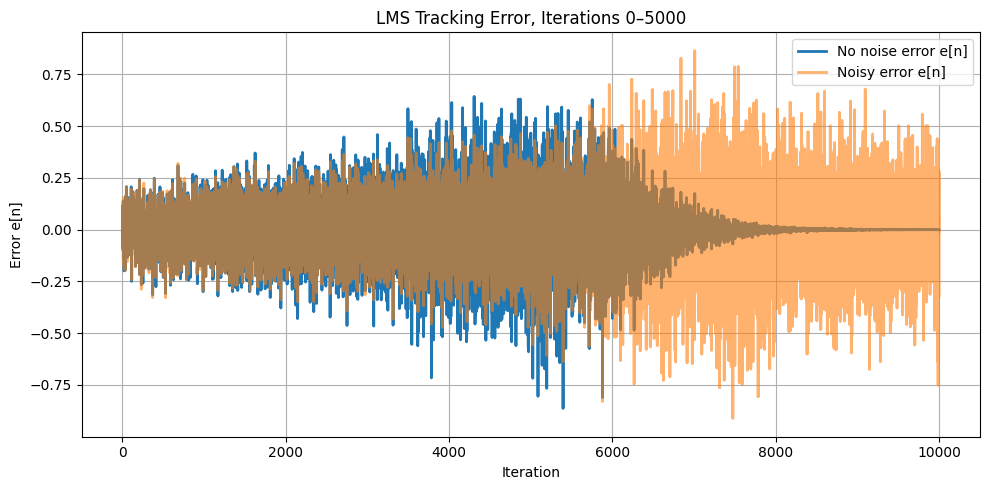

In [13]:
plot_start = 0
plot_end = 10000

iters = np.arange(plot_start, plot_end)

plt.figure(figsize=(10, 5))

plt.plot(
    iters,
    clean["e"][plot_start:plot_end],
    label="No noise error e[n]",
    linewidth=2
)

plt.plot(
    iters,
    noisy["e"][plot_start:plot_end],
    label="Noisy error e[n]",
    linewidth=2,
    alpha=0.6
)

plt.title("LMS Tracking Error, Iterations 0–5000")
plt.xlabel("Iteration")
plt.ylabel("Error e[n]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [529]:
# -------------------------------------------------
# Monte Carlo convergence test using ONLY your function
# -------------------------------------------------

noise_stds = np.array([0.20, 0.25, 0.30, 0.35, 0.40])
trials_per_noise = 10

rows = []
trial_rows = []
tail_start = int(0.8 * N)

for i, ns in enumerate(noise_stds):

    rng_noise = np.random.default_rng(50000 + i)

    noise_bank = ns * rng_noise.standard_normal((N, trials_per_noise))

    w0_values = []
    successes = []

    for t in range(trials_per_noise):

        noise_trial = noise_bank[:, t]

        sim = run_lms_inverse_control(
            r=r,
            h_p=h_p,
            h_m=h_m,
            M=M,
            mu=mu,
            w0=w0,
            noise=noise_trial,
            clean=False
        )

        # Only use w[0]
        w0_tail_mean = np.mean(sim["w_hist"][tail_start:, 0])

        success = w0_tail_mean > 0.5

        w0_values.append(w0_tail_mean)
        successes.append(success)

        trial_rows.append({
            "noise_std": ns,
            "trial": t,
            "w0_tail_mean": w0_tail_mean,
            "success": bool(success),
        })

    w0_values = np.array(w0_values)
    successes = np.array(successes)
    success_rate = np.mean(successes)

    print(
        f"noise_std = {ns:.2f}, "
        f"success_rate = {success_rate:.2f}, "
        f"mean final w[0] = {np.mean(w0_values):.4f}, "
        f"std final w[0] = {np.std(w0_values):.4f}"
    )

noise_std = 0.20, success_rate = 1.00, mean final w[0] = 0.9572, std final w[0] = 0.0012
noise_std = 0.25, success_rate = 1.00, mean final w[0] = 0.9325, std final w[0] = 0.0044
noise_std = 0.30, success_rate = 0.10, mean final w[0] = 0.1491, std final w[0] = 0.2521
noise_std = 0.35, success_rate = 0.00, mean final w[0] = 0.0007, std final w[0] = 0.0001
noise_std = 0.40, success_rate = 0.00, mean final w[0] = 0.0000, std final w[0] = 0.0000


In [520]:
import warnings

mu_values = np.array([0.0001, 0.001, 0.01, 0.1])

noise_std = 0.20
num_runs = 5

tail_start = int(0.8 * N)

rng_noise = np.random.default_rng(60000)
noise_bank = noise_std * rng_noise.standard_normal((N, num_runs))

for mu_test in mu_values:

    successes = 0
    w0_results = []

    for run in range(num_runs):

        noise_trial = noise_bank[:, run]

        # Hide overflow warnings, but still detect failure below
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", RuntimeWarning)

            sim = run_lms_inverse_control(
                r=r,
                h_p=h_p,
                h_m=h_m,
                M=M,
                mu=mu_test,
                w0=w0_init,
                noise=noise_trial,
                clean=False
            )

        w0_tail_mean = np.mean(sim["w_hist"][tail_start:, 0])
        w0_results.append(w0_tail_mean)

        if np.isfinite(w0_tail_mean) and w0_tail_mean > 0.5:
            successes += 1

    success_percent = 100 * successes / num_runs

    finite_w0 = np.array(w0_results)[np.isfinite(w0_results)]

    if len(finite_w0) > 0:
        mean_w0 = np.mean(finite_w0)
    else:
        mean_w0 = np.nan

    if success_percent >= 80:
        status = "WORKS"
    else:
        status = "DOES NOT WORK"

    print(
        f"mu = {mu_test:.4f}, "
        f"success = {success_percent:.0f}%, "
        f"mean final w[0] = {mean_w0:.4f}, "
        f"{status}"
    )

mu = 0.0001, success = 0%, mean final w[0] = 0.1414, DOES NOT WORK
mu = 0.0010, success = 100%, mean final w[0] = 0.9588, WORKS
mu = 0.0100, success = 100%, mean final w[0] = 0.9572, WORKS
mu = 0.1000, success = 40%, mean final w[0] = 0.9349, DOES NOT WORK
